In [27]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("..")) 

from halo_model.power_spectra.matter_power import MatterPower
from halo_model.power_spectra.angular_power import AngularPower
from halo_model.config.config import Config

In [ ]:
#import ingredient models


from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.sheth1999 import MassFuncSheth1999
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO


In [ ]:
cfg = Config()

mass_func = MassFuncSheth1999()

smooth_profile = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))

bias = BiasTinker2010(cfg)

clump_profile = ProfileNFW(ConcentrationPieri2009_clumps(ConcentrationNeto2007(cfg), d_vir=0.3), 
                           R_virSO(cfg))

clump_distribution = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))
clump_mass_func = ClumpMassGiocoli2010(cfg)

In [30]:
Cl = AngularPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)

interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating power spectra over k and z


In [ ]:
l_vals = np.logspace(np.log10(cfg.l_min), np.log10(cfg.l_max), cfg.N_l)
Cl_1h_ss = np.array([Cl.C_1h_ss(l) for l in l_vals])
Cl_1h_sc = np.array([Cl.C_1h_sc(l) for l in l_vals])
Cl_1h_self_c = np.array([Cl.C_1h_self_c(l) for l in l_vals])
Cl_1h_cc = np.array([Cl.C_1h_cc(l) for l in l_vals])
Cl_2h = np.array([Cl.C_2h(l) for l in l_vals])

In [32]:
Cl_tot = Cl_1h_ss + Cl_1h_sc + Cl_1h_self_c + Cl_1h_cc + Cl_2h

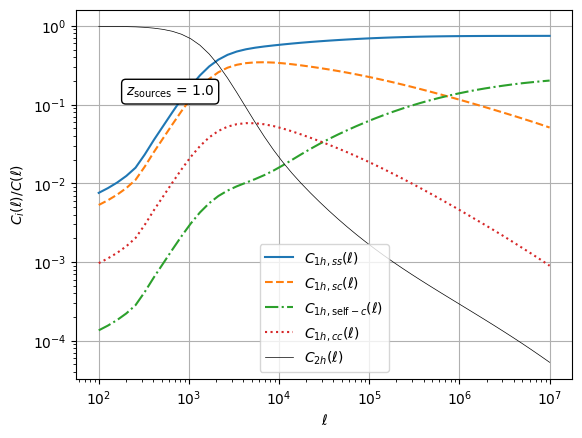

In [ ]:
plt.plot(l_vals, Cl_1h_ss/Cl_tot, label=r'$C_{1h,ss}(\ell)$', linestyle='-')
plt.plot(l_vals, Cl_1h_sc/Cl_tot, label=r'$C_{1h,sc}(\ell)$', linestyle='--')
plt.plot(l_vals, Cl_1h_self_c/Cl_tot, label=r'$C_{1h,\mathrm{self-}c}(\ell)$', linestyle='-.')
plt.plot(l_vals, Cl_1h_cc/Cl_tot, label=r'$C_{1h,cc}(\ell)$', linestyle=':')
plt.plot(l_vals, Cl_2h/Cl_tot, label=r'$C_{2h}(\ell)$', color='black', linewidth=0.5)

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{i}(\ell) / C(\ell)$')

plt.legend()
plt.grid()
plt.loglog()

plt.text(
    0.1, 0.8,
    r"$z_\mathrm{sources}$" +  f" = {cfg.z_sources:.1f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=1)
)

plt.ylim(1e-3, None)
plt.xlim(np.min(l_vals), np.max(l_vals))

plt.savefig("plots_Cl_contributions/Cl_ratios.pdf")
plt.show()